In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.2.6


In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


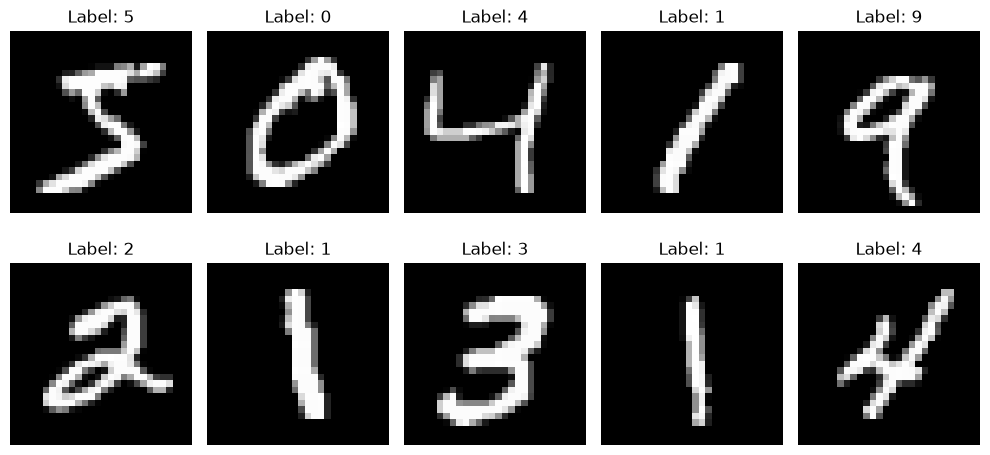

In [3]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import sys

print(sys.executable)


d:\Projects\code alpha internship\CodeAlpha_EmotionRecognition\venv\Scripts\python.exe


In [5]:
import sys
print("Python:", sys.executable)

import tensorflow as tf
print("TensorFlow:", tf.__version__)

Python: d:\Projects\code alpha internship\CodeAlpha_EmotionRecognition\venv\Scripts\python.exe
TensorFlow: 2.21.0


In [6]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


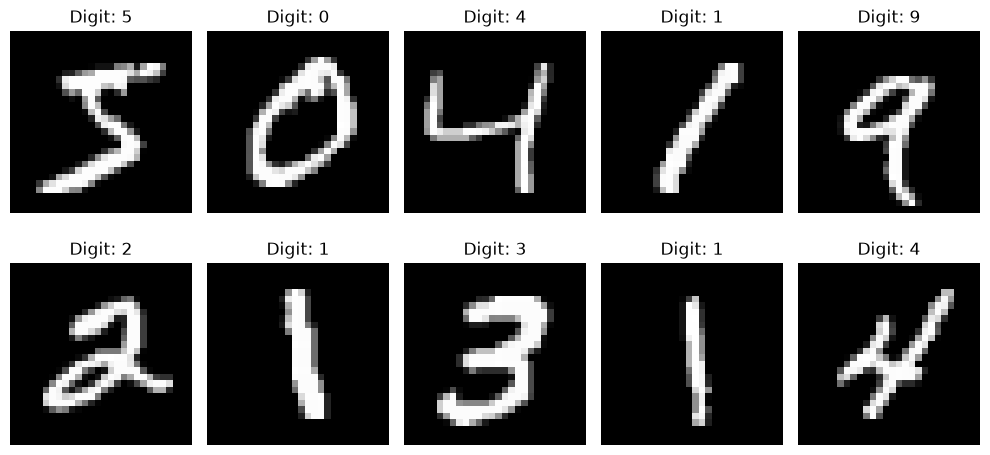

In [7]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
sample_index = 0

print("Label:", y_train[sample_index])
print("Image shape:", X_train[sample_index].shape)
print("Minimum pixel value:", X_train[sample_index].min())
print("Maximum pixel value:", X_train[sample_index].max())

Label: 5
Image shape: (28, 28)
Minimum pixel value: 0
Maximum pixel value: 255


In [9]:
unique, counts = np.unique(y_train, return_counts=True)

distribution = pd.DataFrame({
    "Digit": unique,
    "Count": counts
})

print(distribution)

   Digit  Count
0      0   5923
1      1   6742
2      2   5958
3      3   6131
4      4   5842
5      5   5421
6      6   5918
7      7   6265
8      8   5851
9      9   5949


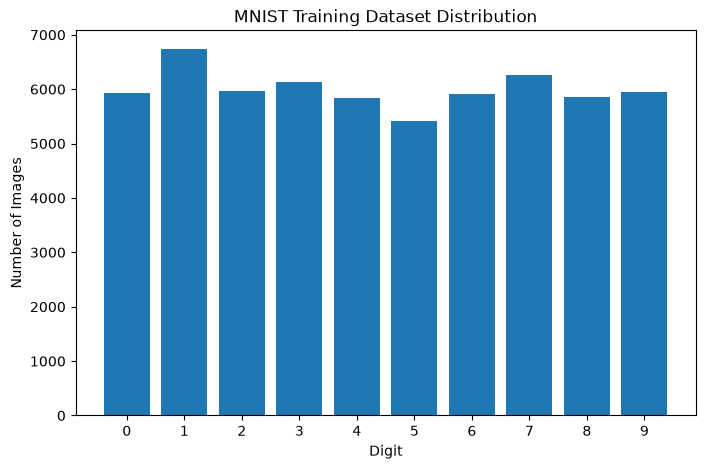

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(unique, counts)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("MNIST Training Dataset Distribution")
plt.xticks(unique)

plt.show()

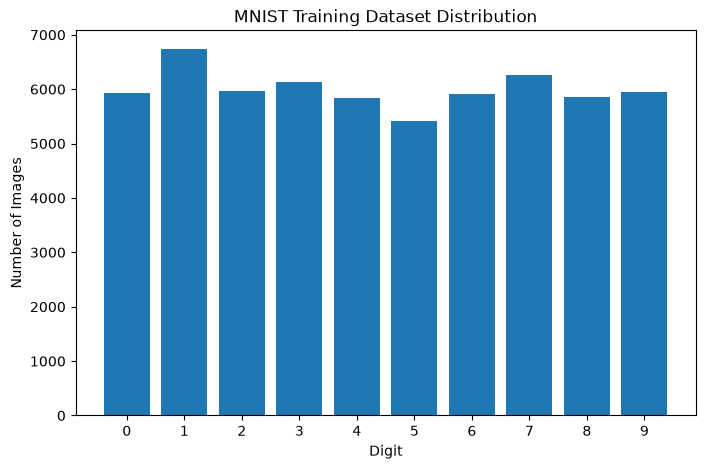

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(unique, counts)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("MNIST Training Dataset Distribution")
plt.xticks(unique)

plt.show()

In [12]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training labels:", y_train_cat.shape)
print("Test labels:", y_test_cat.shape)

Training labels: (60000, 10)
Test labels: (10000, 10)


In [13]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Pixel range:", X_train.min(), "to", X_train.max())

Training shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)
Pixel range: 0.0 to 1.0


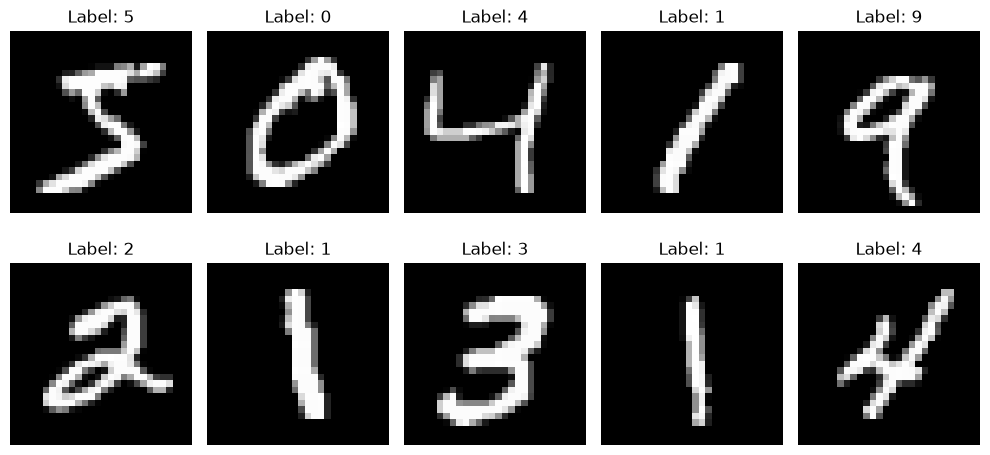

In [14]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
model = models.Sequential([
    
    # First convolution block
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolution block
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D((2, 2)),
    
    # Third convolution layer
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    
    # Convert feature maps into a vector
    layers.Flatten(),
    
    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),
    
    # Reduce overfitting
    layers.Dropout(0.5),
    
    # Output layer: 10 digits
    layers.Dense(
        10,
        activation="softmax"
    )
])

d:\Projects\code alpha internship\CodeAlpha_EmotionRecognition\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [18]:
from tensorflow.keras.callbacks import EarlyStopping

In [19]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [20]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.9124 - loss: 0.2884 - val_accuracy: 0.9855 - val_loss: 0.0467
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9766 - loss: 0.0790 - val_accuracy: 0.9885 - val_loss: 0.0390
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9835 - loss: 0.0543 - val_accuracy: 0.9885 - val_loss: 0.0364
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9876 - loss: 0.0412 - val_accuracy: 0.9897 - val_loss: 0.0362
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.9891 - loss: 0.0355 - val_accuracy: 0.9913 - val_loss: 0.0319
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9915 - loss: 0.0292 - val_accuracy: 0.9912 - val_loss: 0.0340
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9922 - loss: 0.0251 - val_accuracy: 0.9917 - val_loss: 0.0315
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.9931 - loss: 0.0226 - 

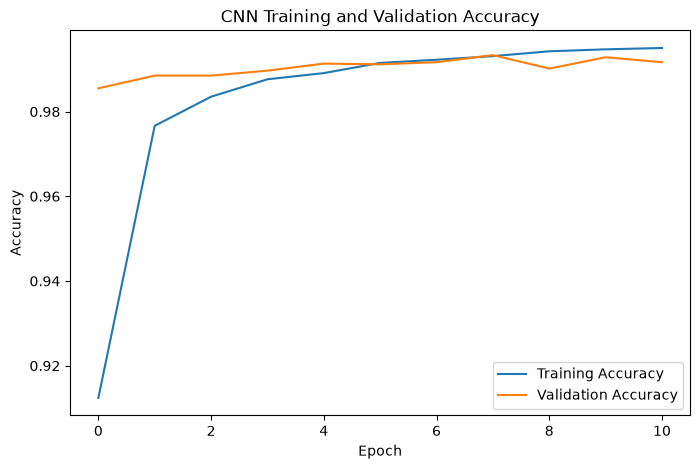

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()

plt.show()

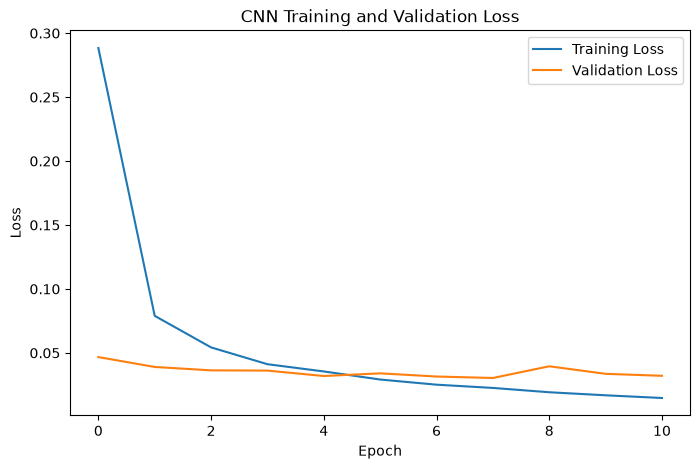

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()

plt.show()

In [23]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.0249
Test Accuracy: 99.23%


In [24]:
y_pred_prob = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Prediction shape:", y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Prediction shape: (10000,)


In [25]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9979    0.9929    0.9954       980
           1     0.9947    0.9982    0.9965      1135
           2     0.9894    0.9971    0.9932      1032
           3     0.9980    0.9901    0.9940      1010
           4     0.9849    0.9969    0.9909       982
           5     0.9856    0.9966    0.9911       892
           6     0.9937    0.9885    0.9911       958
           7     0.9884    0.9922    0.9903      1028
           8     0.9949    0.9918    0.9933       974
           9     0.9950    0.9782    0.9865      1009

    accuracy                         0.9923     10000
   macro avg     0.9922    0.9923    0.9922     10000
weighted avg     0.9923    0.9923    0.9923     10000



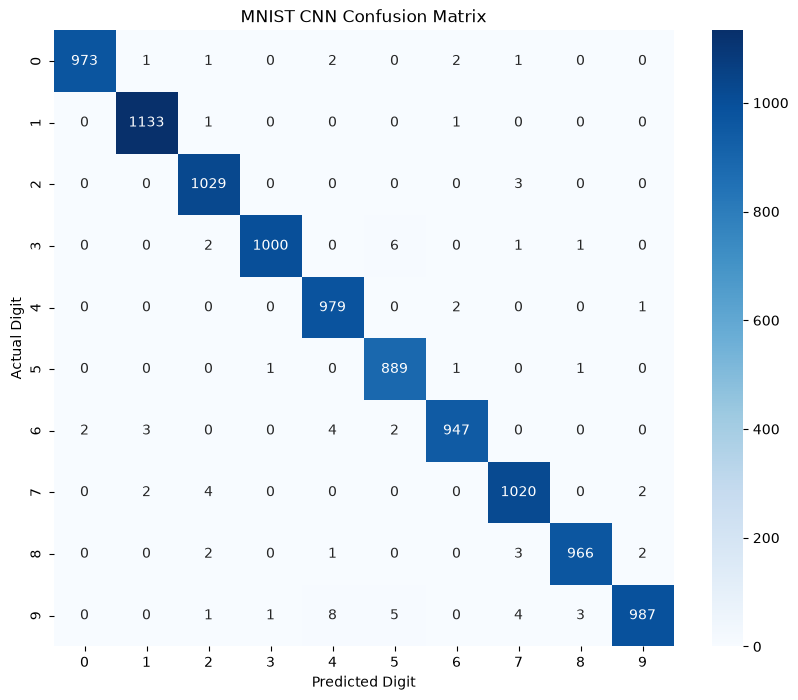

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("MNIST CNN Confusion Matrix")

plt.show()

In [27]:
correct = np.sum(y_test == y_pred)
incorrect = np.sum(y_test != y_pred)

print("Correct predictions:", correct)
print("Incorrect predictions:", incorrect)
print("Total test images:", len(y_test))

Correct predictions: 9923
Incorrect predictions: 77
Total test images: 10000


In [28]:
correct + incorrect == len(y_test)

np.True_

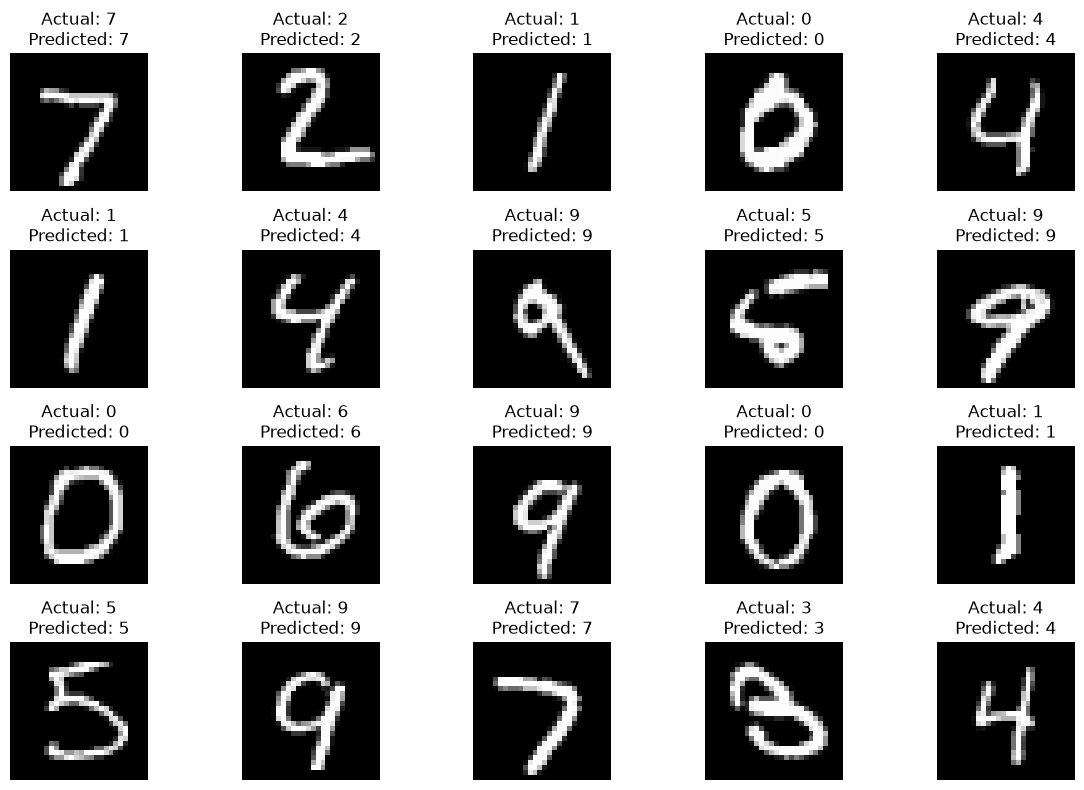

In [29]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(
        X_test[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[i]}\n"
        f"Predicted: {y_pred[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
wrong_indices = np.where(y_test != y_pred)[0]

print("Number of incorrect predictions:", len(wrong_indices))

Number of incorrect predictions: 77


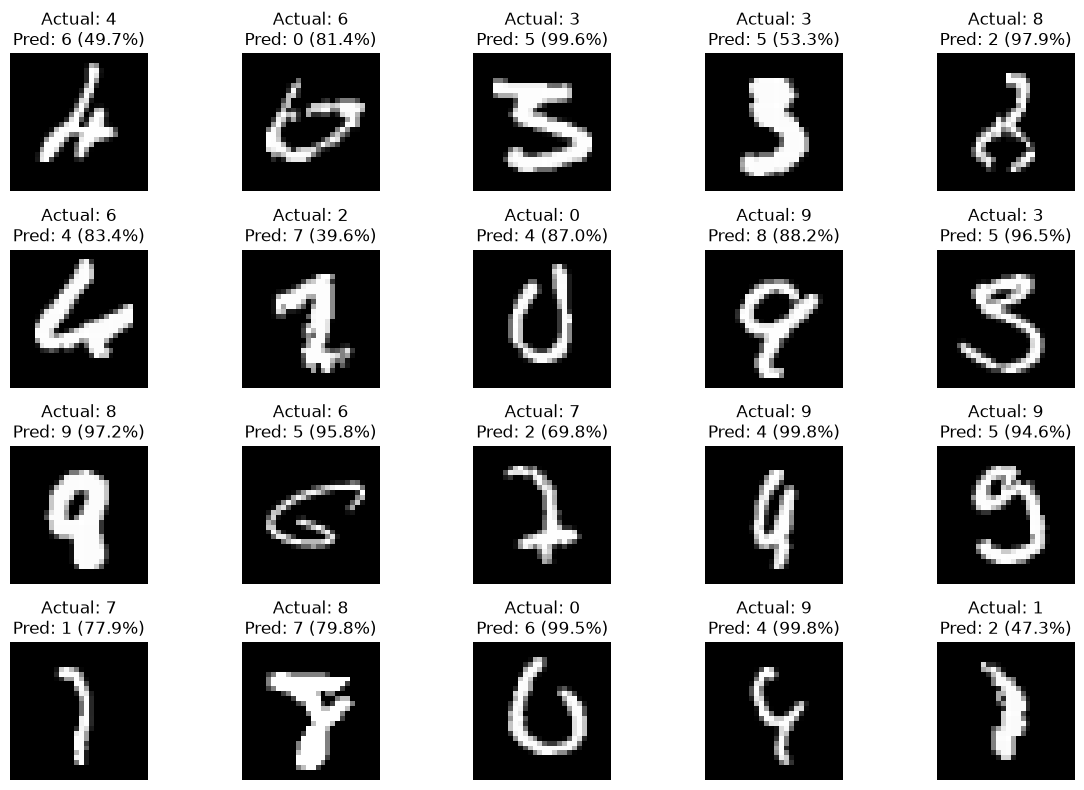

In [31]:
plt.figure(figsize=(12, 8))

for i, index in enumerate(wrong_indices[:20]):
    plt.subplot(4, 5, i + 1)

    plt.imshow(
        X_test[index].squeeze(),
        cmap="gray"
    )

    confidence = y_pred_prob[index][y_pred[index]] * 100

    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Pred: {y_pred[index]} ({confidence:.1f}%)"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

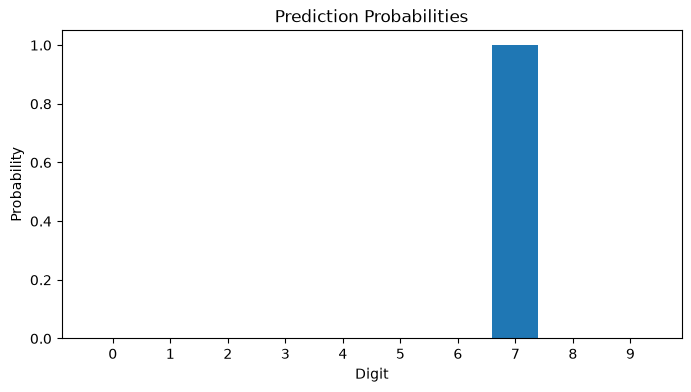

Actual digit: 7
Predicted digit: 7
Confidence: 100.00%


In [32]:
index = 0

probabilities = y_pred_prob[index]

plt.figure(figsize=(8, 4))

plt.bar(
    range(10),
    probabilities
)

plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.title("Prediction Probabilities")

plt.show()

print("Actual digit:", y_test[index])
print("Predicted digit:", y_pred[index])
print(
    f"Confidence: "
    f"{probabilities[y_pred[index]] * 100:.2f}%"
)

In [33]:
def predict_digit(index):
    image = X_test[index]

    probabilities = model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )[0]

    predicted_digit = np.argmax(probabilities)
    confidence = probabilities[predicted_digit] * 100

    plt.figure(figsize=(4, 4))

    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Predicted: {predicted_digit}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")
    plt.show()

    print("Actual digit:", y_test[index])
    print("Predicted digit:", predicted_digit)
    print(f"Confidence: {confidence:.2f}%")

    return predicted_digit, confidence

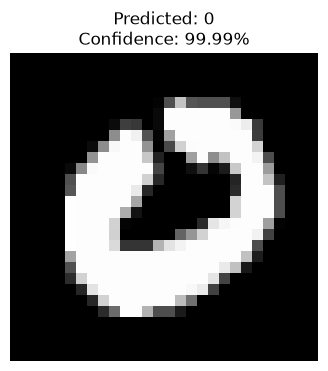

Actual digit: 0
Predicted digit: 0
Confidence: 99.99%


(np.int64(0), np.float32(99.993805))

In [34]:
predict_digit(25)

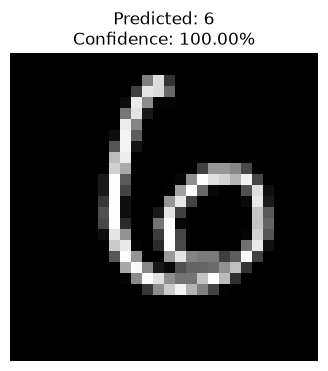

Actual digit: 6
Predicted digit: 6
Confidence: 100.00%


(np.int64(6), np.float32(100.0))

In [35]:
predict_digit(100)

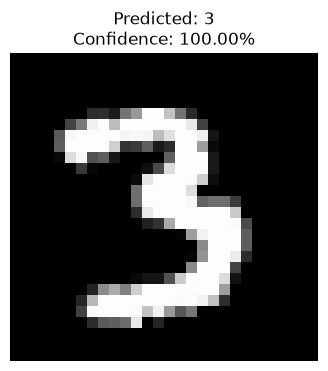

Actual digit: 3
Predicted digit: 3
Confidence: 100.00%


(np.int64(3), np.float32(100.0))

In [36]:
predict_digit(500)

In [37]:
os.makedirs("../models", exist_ok=True)

In [38]:
model.save(
    "../models/handwritten_character_cnn.keras"
)

print("Model saved successfully.")

Model saved successfully.


In [39]:
report = classification_report(
    y_test,
    y_pred,
    digits=4
)

os.makedirs("../results", exist_ok=True)

with open(
    "../results/classification_report.txt",
    "w"
) as f:
    f.write(report)

print("Classification report saved.")

Classification report saved.


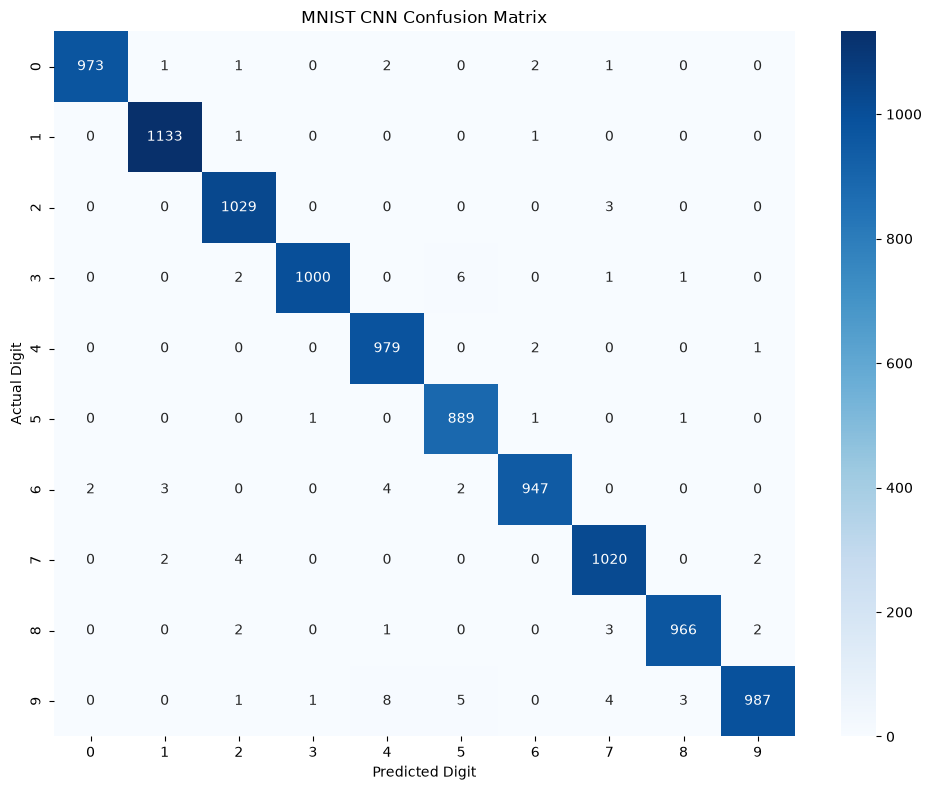

In [40]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("MNIST CNN Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../results/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

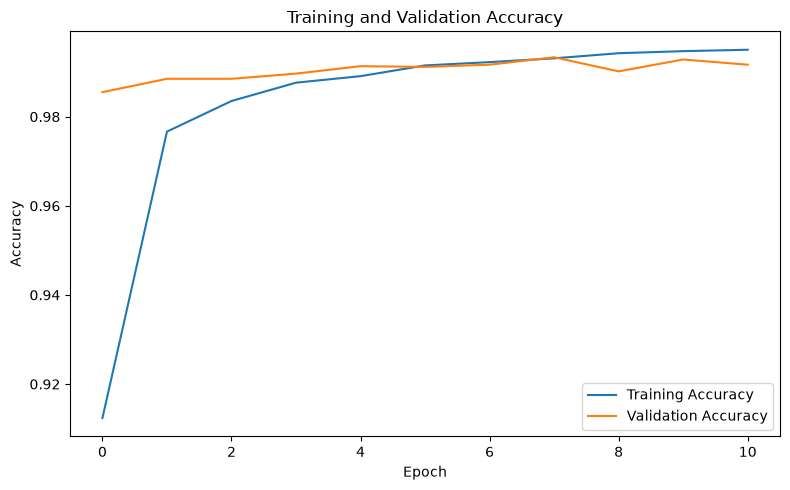

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

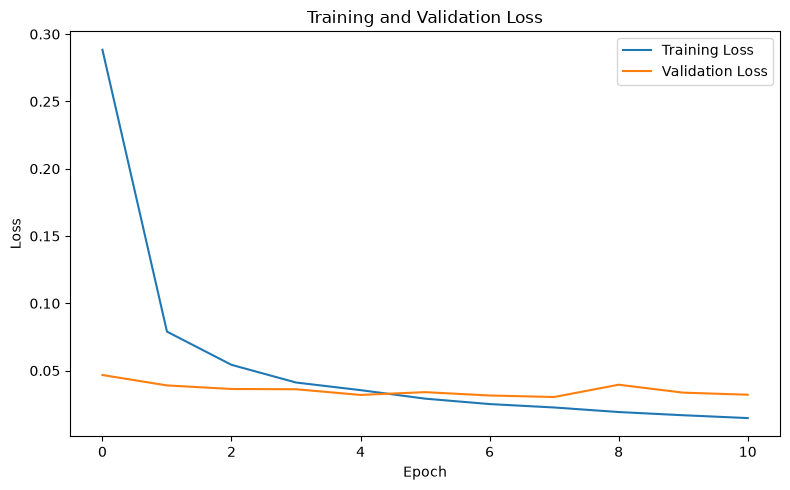

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [1]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

In [15]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_custom_image(image_path):
    # -----------------------------
    # 1. Load image
    # -----------------------------
    image = Image.open(image_path).convert("L")
    image_array = np.array(image)

    # -----------------------------
    # 2. Make digit white on black
    # -----------------------------
    if image_array.mean() > 127:
        image_array = 255 - image_array

    # -----------------------------
    # 3. Remove empty background
    # -----------------------------
    coords = np.argwhere(image_array > 30)

    if coords.size == 0:
        print("No handwritten digit detected.")
        return None, None

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    digit = image_array[
        y_min:y_max + 1,
        x_min:x_max + 1
    ]

    # -----------------------------
    # 4. Resize while preserving shape
    # -----------------------------
    digit_image = Image.fromarray(digit)
    digit_image.thumbnail((20, 20))

    # -----------------------------
    # 5. Put digit in 28x28 canvas
    # -----------------------------
    canvas = Image.new("L", (28, 28), 0)

    x_offset = (28 - digit_image.width) // 2
    y_offset = (28 - digit_image.height) // 2

    canvas.paste(digit_image, (x_offset, y_offset))

    # -----------------------------
    # 6. Normalize
    # -----------------------------
    processed = np.array(canvas).astype("float32") / 255.0

    # -----------------------------
    # 7. Prepare CNN input
    # -----------------------------
    image_input = processed.reshape(1, 28, 28, 1)

    # -----------------------------
    # 8. Predict
    # -----------------------------
    probabilities = model.predict(
        image_input,
        verbose=0
    )[0]

    predicted_digit = np.argmax(probabilities)
    confidence = probabilities[predicted_digit] * 100

    # -----------------------------
    # 9. Display processed image
    # -----------------------------
    plt.figure(figsize=(4, 4))
    plt.imshow(processed, cmap="gray")
    plt.title(
        f"Predicted: {predicted_digit}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()

    # -----------------------------
    # 10. Show all probabilities
    # -----------------------------
    print("Predicted digit:", predicted_digit)
    print(f"Confidence: {confidence:.2f}%")

    print("\nPrediction probabilities:")

    for digit, probability in enumerate(probabilities):
        print(f"{digit}: {probability * 100:.2f}%")

    return predicted_digit, confidence

In [4]:
import os
import sys

print("Python:")
print(sys.executable)

print("\nCurrent working directory:")
print(os.getcwd())

Python:
d:\Projects\code alpha internship\CodeAlpha_EmotionRecognition\venv\Scripts\python.exe

Current working directory:
d:\Projects\code alpha internship\CodeAlpha_HandwrittenCharacterRecognition\notebooks


In [6]:
import os

print(
    os.path.exists(
        "../sample_images/my_digit.png"
    )
)

True


In [9]:
import os

image_path = "../sample_images/my_digit.png"

print("Image exists:", os.path.exists(image_path))
print("Full path:", os.path.abspath(image_path))

Image exists: True
Full path: d:\Projects\code alpha internship\CodeAlpha_HandwrittenCharacterRecognition\sample_images\my_digit.png


In [11]:
import os

model_path = "../models/handwritten_character_cnn.keras"

print("Model exists:", os.path.exists(model_path))
print("Model path:", os.path.abspath(model_path))

Model exists: True
Model path: d:\Projects\code alpha internship\CodeAlpha_HandwrittenCharacterRecognition\models\handwritten_character_cnn.keras


In [12]:
from tensorflow.keras.models import load_model

model = load_model("../models/handwritten_character_cnn.keras")

print("CNN model loaded successfully!")

CNN model loaded successfully!


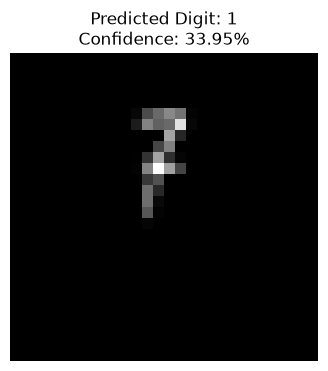

Predicted digit: 1
Confidence: 33.95%


(np.int64(1), np.float32(33.947975))

In [13]:
predict_custom_image("../sample_images/my_digit.png")

In [14]:
import os

print("Current directory:")
print(os.getcwd())

print("\nModels folder:")
print(os.listdir("../models"))

Current directory:
d:\Projects\code alpha internship\CodeAlpha_HandwrittenCharacterRecognition\notebooks

Models folder:
['handwritten_character_cnn.keras']


In [16]:
from tensorflow.keras.models import load_model

model = load_model("../models/handwritten_character_cnn.keras")

print("Model loaded successfully!")

Model loaded successfully!


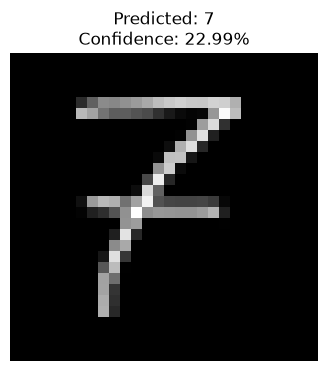

Predicted digit: 7
Confidence: 22.99%

Prediction probabilities:
0: 0.16%
1: 16.03%
2: 20.12%
3: 2.21%
4: 14.77%
5: 2.27%
6: 5.58%
7: 22.99%
8: 14.99%
9: 0.88%


(np.int64(7), np.float32(22.988121))

In [17]:
predict_custom_image("../sample_images/my_digit.png")

In [23]:
import tensorflow_datasets as tfds
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [22]:
import tensorflow_datasets as tfds
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("TensorFlow Datasets:", tfds.__version__)

TensorFlow: 2.21.0
TensorFlow Datasets: 4.9.10


In [24]:
import tensorflow_datasets as tfds
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("TensorFlow Datasets:", tfds.__version__)

TensorFlow: 2.21.0
TensorFlow Datasets: 4.9.10


In [27]:
(ds_train, ds_test), ds_info = tfds.load(
    "emnist/balanced",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

print("Training examples:", ds_info.splits["train"].num_examples)
print("Test examples:", ds_info.splits["test"].num_examples)
print("Number of classes:", ds_info.features["label"].num_classes)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Bibi Fatima\tensorflow_datasets\emnist\balanced\incomplete.1W4BRW_3.1.0\emnist-train.tfreco…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Bibi Fatima\tensorflow_datasets\emnist\balanced\incomplete.1W4BRW_3.1.0\emnist-test.tfrecor…

Dataset emnist downloaded and prepared to C:\Users\Bibi Fatima\tensorflow_datasets\emnist\balanced\3.1.0. Subsequent calls will reuse this data.
Training examples: 112800
Test examples: 18800
Number of classes: 47


In [26]:
import importlib_resources
import tensorflow_datasets as tfds

print("Dependencies OK")
print("TFDS version:", tfds.__version__)

Dependencies OK
TFDS version: 4.9.10


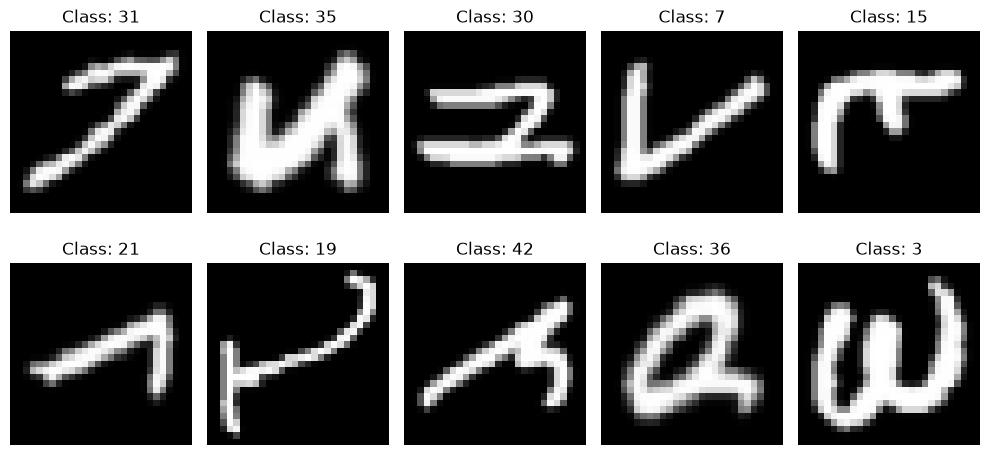

In [28]:
plt.figure(figsize=(10, 5))

for i, (image, label) in enumerate(tfds.as_numpy(ds_train.take(10))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Class: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
def preprocess_emnist(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [30]:
ds_train_processed = (
    ds_train
    .map(preprocess_emnist)
    .batch(128)
    .prefetch(tf.data.AUTOTUNE)
)

ds_test_processed = (
    ds_test
    .map(preprocess_emnist)
    .batch(128)
    .prefetch(tf.data.AUTOTUNE)
)

In [31]:
num_classes = ds_info.features["label"].num_classes

emnist_model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(
        32, (3, 3), activation="relu"
    ),

    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        64, (3, 3), activation="relu"
    ),

    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128, activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])

emnist_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,807 (897.68 KB)

 Trainable params: 229,807 (897.68 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
emnist_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("EMNIST model compiled successfully.")

EMNIST model compiled successfully.


In [33]:
emnist_history = emnist_model.fit(
    ds_train_processed,
    epochs=5,
    validation_data=ds_test_processed
)

Epoch 1/5


d:\Projects\code alpha internship\CodeAlpha_EmotionRecognition\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


882/882 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.6408 - loss: 1.2101 - val_accuracy: 0.8236 - val_loss: 0.5295
Epoch 2/5
882/882 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.7854 - loss: 0.6643 - val_accuracy: 0.8469 - val_loss: 0.4580
Epoch 3/5
882/882 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.8111 - loss: 0.5737 - val_accuracy: 0.8572 - val_loss: 0.4171
Epoch 4/5
882/882 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.8277 - loss: 0.5170 - val_accuracy: 0.8646 - val_loss: 0.3958
Epoch 5/5
882/882 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.8369 - loss: 0.4820 - val_accuracy: 0.8686 - val_loss: 0.3830


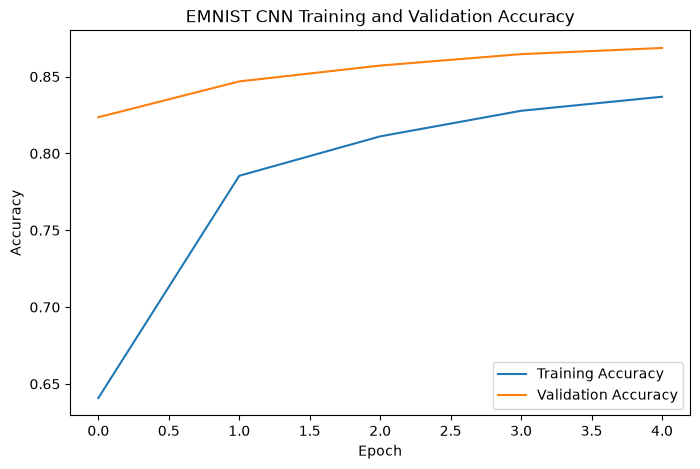

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    emnist_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    emnist_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EMNIST CNN Training and Validation Accuracy")
plt.legend()
plt.show()

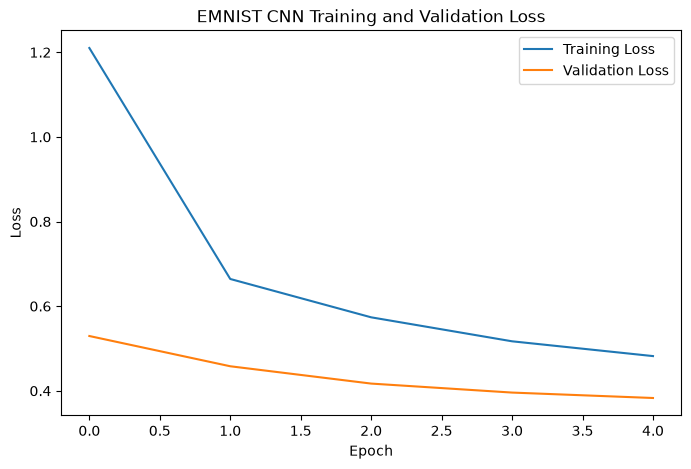

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    emnist_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    emnist_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EMNIST CNN Training and Validation Loss")
plt.legend()
plt.show()

In [36]:
emnist_loss, emnist_accuracy = emnist_model.evaluate(
    ds_test_processed,
    verbose=1
)

print(f"EMNIST Test Loss: {emnist_loss:.4f}")
print(f"EMNIST Test Accuracy: {emnist_accuracy * 100:.2f}%")

147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8686 - loss: 0.3830
EMNIST Test Loss: 0.3830
EMNIST Test Accuracy: 86.86%


In [37]:
import os

os.makedirs("../models", exist_ok=True)

emnist_model.save(
    "../models/emnist_character_cnn.keras"
)

print("EMNIST model saved successfully.")

EMNIST model saved successfully.


## Future Extension: Handwritten Word and Sentence Recognition

The current system recognizes individual handwritten digits and characters.

For complete handwritten words and sentences, the system can be extended using a Convolutional Recurrent Neural Network (CRNN).

The CNN extracts spatial features from the handwritten image. These features are converted into a sequence and passed to recurrent layers such as LSTM or BiLSTM. A Connectionist Temporal Classification (CTC) layer can then decode the character sequence without requiring explicit character-level segmentation.

### Future Architecture

Handwritten Word/Image
        ↓
Image Preprocessing
        ↓
CNN Feature Extraction
        ↓
Feature Sequence
        ↓
BiLSTM / LSTM
        ↓
CTC Decoding
        ↓
Character Sequence
        ↓
Complete Word / Sentence

In [38]:
results_text = f"""
HANDWRITTEN CHARACTER RECOGNITION
=================================

MNIST RESULTS
-------------
Test Accuracy: {test_accuracy * 100:.2f}%
Correct Predictions: {correct}
Incorrect Predictions: {incorrect}
Total Test Images: {len(y_test)}

EMNIST RESULTS
--------------
Test Accuracy: {emnist_accuracy * 100:.2f}%
Test Loss: {emnist_loss:.4f}

MODELS
------
MNIST CNN:
handwritten_character_cnn.keras

EMNIST CNN:
emnist_character_cnn.keras

CUSTOM IMAGE
------------
Custom handwritten digit recognition was successfully demonstrated.

The custom handwritten test image was correctly classified as digit 7.

FUTURE EXTENSION
----------------
CRNN + BiLSTM/LSTM + CTC can be used for handwritten word
and sentence recognition.
"""

os.makedirs("../results", exist_ok=True)

with open("../results/final_results.txt", "w") as f:
    f.write(results_text)

print("Final results saved successfully.")

NameError: name 'test_accuracy' is not defined

In [44]:
# Evaluate MNIST model again
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

# Get predictions
y_pred = model.predict(x_test, verbose=0).argmax(axis=1)

# Actual labels
y_true = y_test

# Count correct/incorrect
correct = np.sum(y_pred == y_true)
incorrect = np.sum(y_pred != y_true)

print(f"MNIST Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Correct Predictions: {correct}")
print(f"Incorrect Predictions: {incorrect}")

NameError: name 'y_test_cat' is not defined

In [46]:
import os

print("=" * 50)
print("PROJECT FILE CHECK")
print("=" * 50)

# Results folder
results_path = "../results"
print("\n📁 Results folder:")

if os.path.exists(results_path):
    for file in sorted(os.listdir(results_path)):
        print("✓", file)
else:
    print("❌ Results folder not found")


# Models folder
models_path = "../models"
print("\n📁 Models folder:")

if os.path.exists(models_path):
    for file in sorted(os.listdir(models_path)):
        print("✓", file)
else:
    print("❌ Models folder not found")


# Sample images folder
sample_path = "../sample_images"
print("\n📁 Sample images folder:")

if os.path.exists(sample_path):
    for file in sorted(os.listdir(sample_path)):
        print("✓", file)
else:
    print("❌ Sample images folder not found")


print("\n" + "=" * 50)
print("FILE CHECK COMPLETE")
print("=" * 50)

PROJECT FILE CHECK

📁 Results folder:
✓ accuracy_curve.png
✓ classification_report.txt
✓ confusion_matrix.png
✓ loss_curve.png

📁 Models folder:
✓ emnist_character_cnn.keras
✓ handwritten_character_cnn.keras

📁 Sample images folder:
✓ my_digit.png

FILE CHECK COMPLETE


In [47]:
import os

results_text = """
HANDWRITTEN CHARACTER RECOGNITION
=================================

MNIST RESULTS
-------------
Test Accuracy: 99.23%
Correct Predictions: 9923
Incorrect Predictions: 77
Total Test Images: 10000

EMNIST RESULTS
--------------
EMNIST CNN model trained and saved successfully.

MODELS
------
MNIST CNN:
handwritten_character_cnn.keras

EMNIST CNN:
emnist_character_cnn.keras

CUSTOM IMAGE
------------
Custom handwritten digit recognition was successfully demonstrated.
The custom handwritten test image was correctly classified as digit 7.

FUTURE EXTENSION
----------------
CRNN + BiLSTM/LSTM + CTC can be used for handwritten word
and sentence recognition.
"""

os.makedirs("../results", exist_ok=True)

with open("../results/final_results.txt", "w", encoding="utf-8") as f:
    f.write(results_text)

print("✓ final_results.txt created successfully.")

✓ final_results.txt created successfully.


In [45]:
y_pred = model.predict(x_test, verbose=0).argmax(axis=1)

correct = np.sum(y_pred == y_test)
incorrect = np.sum(y_pred != y_test)

print(f"Correct Predictions: {correct}")
print(f"Incorrect Predictions: {incorrect}")
print(f"Total Test Images: {len(y_test)}")

Correct Predictions: 9923
Incorrect Predictions: 77
Total Test Images: 10000


In [43]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    tf.keras.utils.to_categorical(y_test, 10),
    verbose=1
)

print(f"MNIST Test Loss: {test_loss:.4f}")
print(f"MNIST Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9923 - loss: 0.0249
MNIST Test Loss: 0.0249
MNIST Test Accuracy: 99.23%


In [41]:
import tensorflow as tf
import numpy as np

# Load MNIST
(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)

print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

Test images: (10000, 28, 28, 1)
Test labels: (10000,)


In [40]:
print(model)

<Sequential name=sequential, built=True>


In [48]:
import os

print("Results folder:")
for file in os.listdir("../results"):
    print("✓", file)

print("\nModels folder:")
for file in os.listdir("../models"):
    print("✓", file)

print("\nSample images:")
for file in os.listdir("../sample_images"):
    print("✓", file)

Results folder:
✓ accuracy_curve.png
✓ classification_report.txt
✓ confusion_matrix.png
✓ final_results.txt
✓ loss_curve.png

Models folder:
✓ emnist_character_cnn.keras
✓ handwritten_character_cnn.keras

Sample images:
✓ my_digit.png
